In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# 随机种子（和昨天保持一致）
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 库导入成功")
print(f"   设备：{device}")
print(f"   PyTorch版本：{torch.__version__}")

✅ 库导入成功
   设备：cpu
   PyTorch版本：2.13.0+cpu


In [2]:
# 加载特征矩阵
df = pd.read_csv("../data/processed/plaid_rotor37_features.csv")

input_cols  = [c for c in df.columns 
               if c not in ['sample_id', 'Compression_ratio',
                            'Efficiency', 'Massflow']]
output_cols = ['Compression_ratio', 'Efficiency', 'Massflow']

X_raw = df[input_cols].values.astype(np.float32)
y_raw = df[output_cols].values.astype(np.float32)

# 划分数据集（随机种子一致，保证和昨天是同一个划分）
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.10, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=SEED)

# 标准化
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)

# 保存新的 scaler
joblib.dump(scaler_X, "../models/scaler_X_v2.pkl")
joblib.dump(scaler_y, "../models/scaler_y_v2.pkl")

print(f"✅ 数据加载完成")
print(f"   训练集：{X_train_sc.shape}")
print(f"   验证集：{X_val_sc.shape}")
print(f"   测试集：{X_test_sc.shape}")
print(f"   输入维度：{X_train_sc.shape[1]}")

# 记录输出的物理范围（用于物理约束）
y_train_min = y_train.min(axis=0)
y_train_max = y_train.max(axis=0)
print(f"\n输出变量的物理范围（原始量纲）：")
for i, col in enumerate(output_cols):
    print(f"  {col}: [{y_train_min[i]:.4f}, {y_train_max[i]:.4f}]")

✅ 数据加载完成
   训练集：(800, 74)
   验证集：(100, 74)
   测试集：(100, 74)
   输入维度：74

输出变量的物理范围（原始量纲）：
  Compression_ratio: [1.8285, 2.1167]
  Efficiency: [0.8464, 0.8914]
  Massflow: [18.0078, 20.8432]


In [3]:
class TurbineDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_loader = DataLoader(TurbineDataset(X_train_sc, y_train_sc),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TurbineDataset(X_val_sc,   y_val_sc),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TurbineDataset(X_test_sc,  y_test_sc),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoader 创建成功")
X_b, y_b = next(iter(train_loader))
print(f"   Batch形状：X={X_b.shape}, y={y_b.shape}")

✅ DataLoader 创建成功
   Batch形状：X=torch.Size([32, 74]), y=torch.Size([32, 3])


In [4]:
# ── 什么是残差连接？ ──────────────────────────────────────
# 普通MLP：x → 变换 → 输出
# 残差网络：x → 变换 → 输出 + x（把输入直接加到输出上）
#
# 好处：
# 1. 梯度可以直接"跳过"某些层流回去，不会消失
# 2. 最差情况下，残差块可以学成"什么都不做"（恒等映射）
# 3. 允许网络更深，学到更复杂的特征

class ResidualBlock(nn.Module):
    """
    残差块：
    输入 x (dim)
        ├─→ Linear(dim) → BN → ReLU → Dropout → Linear(dim) → BN
        └─────────────────────────────────────────────────────┐
                                                              ↓
                                                         输出 = 变换(x) + x → ReLU
    """
    def __init__(self, dim, dropout=0.1):
        super(ResidualBlock, self).__init__()
        
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # 残差连接：把变换结果和原始输入相加
        return self.relu(self.block(x) + x)


# 验证残差块
test_block = ResidualBlock(dim=256)
test_input = torch.randn(32, 256)
test_output = test_block(test_input)
print(f"✅ 残差块定义成功")
print(f"   输入形状：{test_input.shape}")
print(f"   输出形状：{test_output.shape}")
print(f"   形状保持不变 → 残差连接正确 ✅")

✅ 残差块定义成功
   输入形状：torch.Size([32, 256])
   输出形状：torch.Size([32, 256])
   形状保持不变 → 残差连接正确 ✅


In [5]:
class ResidualSurrogateModel(nn.Module):
    """
    叶轮机械气动性能深度学习代理模型（残差版本）
    
    架构：
    输入(74)
        → 输入投影层 Linear(74→256) + BN + ReLU
        → 残差块1 (256→256)
        → 残差块2 (256→256)
        → 残差块3 (256→256)
        → 中间投影 Linear(256→128) + BN + ReLU
        → 残差块4 (128→128)
        → 残差块5 (128→128)
        → 输出层 Linear(128→3)
    
    共 ~200K 参数，比基线MLP更深但更稳定
    """
    def __init__(self, input_dim=74, output_dim=3, dropout=0.1):
        super(ResidualSurrogateModel, self).__init__()
        
        # 输入投影：把74维升到256维
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        # 第一组残差块（256维）
        self.res_blocks_256 = nn.Sequential(
            ResidualBlock(256, dropout),
            ResidualBlock(256, dropout),
            ResidualBlock(256, dropout),
        )
        
        # 中间投影：256 → 128
        self.mid_proj = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        # 第二组残差块（128维）
        self.res_blocks_128 = nn.Sequential(
            ResidualBlock(128, dropout),
            ResidualBlock(128, dropout),
        )
        
        # 输出层
        self.output_layer = nn.Linear(128, output_dim)
        
        # 权重初始化
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks_256(x)
        x = self.mid_proj(x)
        x = self.res_blocks_128(x)
        x = self.output_layer(x)
        return x


# 实例化模型
model_res = ResidualSurrogateModel(
    input_dim=X_train_sc.shape[1],
    output_dim=3,
    dropout=0.1
).to(device)

# 打印参数量
total_params = sum(p.numel() for p in model_res.parameters())
print(f"✅ 残差网络定义成功")
print(f"   总参数量：{total_params:,}")

# 验证前向传播
test_x = torch.randn(32, X_train_sc.shape[1]).to(device)
test_y = model_res(test_x)
print(f"   输入形状：{test_x.shape}")
print(f"   输出形状：{test_y.shape}")
print(f"   前向传播正常 ✅")

✅ 残差网络定义成功
   总参数量：518,147
   输入形状：torch.Size([32, 74])
   输出形状：torch.Size([32, 3])
   前向传播正常 ✅


In [6]:
# ── 什么是物理约束？为什么要加？ ─────────────────────────
# 普通MSE损失只关心"预测值和真实值差多少"
# 但有时候模型会给出物理上不可能的预测，比如：
#   效率 > 1（违反热力学第二定律）
#   压比 < 1（压气机变成了膨胀机）
#
# 物理约束损失 = MSE损失 + 惩罚项
# 惩罚项：如果预测值违反物理规律，就加一个额外的损失
# 这样模型会"害怕"产生违反物理的预测

# 用 scaler_y 把物理边界转换到标准化空间
# 原始物理边界
EFFICIENCY_MAX  = 1.0     # 效率不能超过1（热力学第二定律）
EFFICIENCY_MIN  = 0.5     # 效率不应低于0.5（极端失速工况）
COMP_RATIO_MIN  = 1.0     # 压比必须大于1（压气机定义）
MASSFLOW_MIN    = 0.0     # 质量流量必须为正

# 把边界转换到标准化空间（模型输出的是标准化值）
def to_scaled(raw_val, col_idx):
    """把原始物理值转换到标准化空间"""
    raw_arr = np.zeros((1, 3))
    raw_arr[0, col_idx] = raw_val
    scaled = scaler_y.transform(raw_arr)
    return float(scaled[0, col_idx])

eff_max_scaled  = to_scaled(EFFICIENCY_MAX,  1)  # Efficiency 是第1列
eff_min_scaled  = to_scaled(EFFICIENCY_MIN,  1)
comp_min_scaled = to_scaled(COMP_RATIO_MIN,  0)  # Compression_ratio 是第0列
mass_min_scaled = to_scaled(MASSFLOW_MIN,    2)  # Massflow 是第2列

print(f"物理边界（标准化空间）：")
print(f"  效率上界：{eff_max_scaled:.4f}（原始=1.0）")
print(f"  效率下界：{eff_min_scaled:.4f}（原始=0.5）")
print(f"  压比下界：{comp_min_scaled:.4f}（原始=1.0）")
print(f"  质量流量下界：{mass_min_scaled:.4f}（原始=0.0）")


class PhysicsConstrainedLoss(nn.Module):
    """
    物理约束损失函数
    
    总损失 = MSE损失 + λ × 物理约束惩罚项
    
    物理约束：
    1. 效率 ≤ 1（热力学第二定律）
    2. 效率 ≥ 0.5（防止极端预测）
    3. 压比 ≥ 1（压气机定义）
    4. 质量流量 ≥ 0（物理常识）
    5. Omega↑ → 压比↑ 单调性约束（转速越高压比越大）
    """
    def __init__(self, lambda_physics=0.1):
        super(PhysicsConstrainedLoss, self).__init__()
        self.mse   = nn.MSELoss()
        self.lam   = lambda_physics  # 物理约束的权重
    
    def forward(self, y_pred, y_true, x_input=None):
        # ── 基础 MSE 损失 ─────────────────────────────────
        mse_loss = self.mse(y_pred, y_true)
        
        # ── 物理约束惩罚 ──────────────────────────────────
        comp_pred = y_pred[:, 0]   # 压比预测
        eff_pred  = y_pred[:, 1]   # 效率预测
        mass_pred = y_pred[:, 2]   # 质量流量预测
        
        # 约束1：效率上界（不能超过1）
        # relu(eff - eff_max) 当 eff > eff_max 时为正，否则为0
        penalty_eff_upper = torch.relu(eff_pred - eff_max_scaled).pow(2).mean()
        
        # 约束2：效率下界（不能低于0.5）
        penalty_eff_lower = torch.relu(eff_min_scaled - eff_pred).pow(2).mean()
        
        # 约束3：压比下界（必须大于1）
        penalty_comp = torch.relu(comp_min_scaled - comp_pred).pow(2).mean()
        
        # 约束4：质量流量下界（必须为正）
        penalty_mass = torch.relu(mass_min_scaled - mass_pred).pow(2).mean()
        
        # 汇总物理约束惩罚
        physics_penalty = (penalty_eff_upper + penalty_eff_lower +
                          penalty_comp + penalty_mass)
        
        # 总损失
        total_loss = mse_loss + self.lam * physics_penalty
        
        return total_loss, mse_loss, physics_penalty


# 测试损失函数
criterion_physics = PhysicsConstrainedLoss(lambda_physics=0.1)
test_pred = torch.randn(32, 3)
test_true = torch.randn(32, 3)
total, mse, phys = criterion_physics(test_pred, test_true)
print(f"\n✅ 物理约束损失函数定义成功")
print(f"   测试：total={total:.4f}, mse={mse:.4f}, physics={phys:.4f}")

物理边界（标准化空间）：
  效率上界：14.4590（原始=1.0）
  效率下界：-41.3062（原始=0.5）
  压比下界：-15.1908（原始=1.0）
  质量流量下界：-30.8655（原始=0.0）

✅ 物理约束损失函数定义成功
   测试：total=2.5063, mse=2.5063, physics=0.0000


In [7]:
# ── 为什么要加权重？ ──────────────────────────────────────
# 昨天的结果：
#   Compression_ratio R² = 0.966  ✅
#   Efficiency        R² = 0.913  ⚠️ 最差
#   Massflow          R² = 0.949  ⚠️
#
# 问题：三个输出的量纲和变化范围不同
#   压比变化范围：~0.29（最大-最小）
#   效率变化范围：~0.045（非常小！）
#   质量流量变化范围：~2.8
#
# 效率的变化范围最小，MSE损失对它的"关注度"最低
# 解决方法：给效率更高的损失权重

# 多任务损失权重（效率权重设为最高）
TASK_WEIGHTS = torch.tensor([1.0, 3.0, 1.5], dtype=torch.float32).to(device)
# 含义：效率的损失权重是压比的3倍，质量流量是1.5倍

print("多任务损失权重：")
for col, w in zip(output_cols, TASK_WEIGHTS.cpu().numpy()):
    print(f"  {col}: {w:.1f}x")

class WeightedPhysicsLoss(nn.Module):
    """
    带多任务权重的物理约束损失
    = 加权MSE + 物理约束惩罚
    """
    def __init__(self, task_weights, lambda_physics=0.1):
        super(WeightedPhysicsLoss, self).__init__()
        self.weights = task_weights
        self.lam     = lambda_physics
    
    def forward(self, y_pred, y_true, x_input=None):
        # 加权 MSE：每个输出单独算MSE，然后加权求和
        mse_per_task = ((y_pred - y_true) ** 2).mean(dim=0)  # shape: (3,)
        weighted_mse = (mse_per_task * self.weights).sum()
        
        # 物理约束
        comp_pred = y_pred[:, 0]
        eff_pred  = y_pred[:, 1]
        mass_pred = y_pred[:, 2]
        
        penalty  = torch.relu(eff_pred  - eff_max_scaled).pow(2).mean()
        penalty += torch.relu(eff_min_scaled - eff_pred).pow(2).mean()
        penalty += torch.relu(comp_min_scaled - comp_pred).pow(2).mean()
        penalty += torch.relu(mass_min_scaled - mass_pred).pow(2).mean()
        
        total = weighted_mse + self.lam * penalty
        return total, weighted_mse, penalty


criterion = WeightedPhysicsLoss(
    task_weights=TASK_WEIGHTS,
    lambda_physics=0.1
)
print(f"\n✅ 多任务物理约束损失函数定义成功")

多任务损失权重：
  Compression_ratio: 1.0x
  Efficiency: 3.0x
  Massflow: 1.5x

✅ 多任务物理约束损失函数定义成功


In [8]:
optimizer = optim.Adam(model_res.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=300, eta_min=1e-5
)
# CosineAnnealingLR：学习率按余弦曲线从初始值慢慢降到最小值
# 比 ReduceLROnPlateau 更平滑，对残差网络更友好

NUM_EPOCHS = 300
PATIENCE   = 40

print(f"✅ 训练配置完成")
print(f"   模型：ResidualSurrogateModel")
print(f"   损失：WeightedPhysicsLoss（效率权重×3）")
print(f"   优化器：Adam (lr=1e-3)")
print(f"   调度器：CosineAnnealingLR (T_max=300)")
print(f"   最大轮数：{NUM_EPOCHS}")
print(f"   早停耐心：{PATIENCE}")

✅ 训练配置完成
   模型：ResidualSurrogateModel
   损失：WeightedPhysicsLoss（效率权重×3）
   优化器：Adam (lr=1e-3)
   调度器：CosineAnnealingLR (T_max=300)
   最大轮数：300
   早停耐心：40


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss, _, _ = criterion(y_pred, y_batch)
        loss.backward()
        # 梯度裁剪：防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss, _, _ = criterion(y_pred, y_batch)
            total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


print("=" * 60)
print("开始训练残差网络 + 物理约束")
print("=" * 60)

train_losses = []
val_losses   = []
best_val_loss    = float('inf')
best_epoch       = 0
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model_res, train_loader,
                                 criterion, optimizer, device)
    val_loss   = evaluate(model_res, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_epoch       = epoch + 1
        patience_counter = 0
        torch.save(model_res.state_dict(),
                   "../models/residual_physics_best.pth")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train: {train_loss:.6f} | "
              f"Val: {val_loss:.6f} | "
              f"Best: Ep{best_epoch}({best_val_loss:.6f}) | "
              f"LR: {lr_now:.2e}")

    if patience_counter >= PATIENCE:
        print(f"\n⏹ 早停！连续{PATIENCE}轮未改善，最优在第{best_epoch}轮")
        break

print(f"\n✅ 训练完成！最优模型已保存。")

开始训练残差网络 + 物理约束
  Epoch   5/300 | Train: 2.835084 | Val: 1.870512 | Best: Ep4(1.594920) | LR: 9.99e-04
  Epoch  10/300 | Train: 1.580726 | Val: 0.848522 | Best: Ep10(0.848522) | LR: 9.97e-04
  Epoch  15/300 | Train: 1.104884 | Val: 0.670518 | Best: Ep15(0.670518) | LR: 9.94e-04
  Epoch  20/300 | Train: 0.998332 | Val: 0.521457 | Best: Ep19(0.498580) | LR: 9.89e-04
  Epoch  25/300 | Train: 0.738319 | Val: 0.412760 | Best: Ep25(0.412760) | LR: 9.83e-04
  Epoch  30/300 | Train: 0.750794 | Val: 0.435139 | Best: Ep28(0.385856) | LR: 9.76e-04
  Epoch  35/300 | Train: 0.706565 | Val: 0.415571 | Best: Ep28(0.385856) | LR: 9.67e-04
  Epoch  40/300 | Train: 0.505930 | Val: 0.358437 | Best: Ep37(0.355073) | LR: 9.57e-04
  Epoch  45/300 | Train: 0.492116 | Val: 0.294978 | Best: Ep45(0.294978) | LR: 9.46e-04
  Epoch  50/300 | Train: 0.512389 | Val: 0.327739 | Best: Ep48(0.290742) | LR: 9.34e-04
  Epoch  55/300 | Train: 0.428495 | Val: 0.259735 | Best: Ep55(0.259735) | LR: 9.20e-04
  Epoch  60/300 |

In [10]:
# 加载最优模型
model_res.load_state_dict(
    torch.load("../models/residual_physics_best.pth", map_location=device)
)
model_res.eval()

# 收集预测结果
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model_res(X_batch.to(device)).cpu().numpy()
        all_preds.append(y_pred)
        all_true.append(y_batch.numpy())

y_pred_sc   = np.vstack(all_preds)
y_true_sc   = np.vstack(all_true)
y_pred_orig = scaler_y.inverse_transform(y_pred_sc)
y_true_orig = scaler_y.inverse_transform(y_true_sc)

# 基线结果（昨天的）
baseline_r2 = [0.966380, 0.913209, 0.949184]

print("=" * 65)
print("测试集性能对比：基线MLP vs 残差网络+物理约束")
print("=" * 65)
print(f"{'指标':<25} {'基线MLP R²':>12} {'残差网络 R²':>12} {'提升':>8}")
print("-" * 65)

r2_scores = []
for i, col in enumerate(output_cols):
    r2  = r2_score(y_true_orig[:, i], y_pred_orig[:, i])
    mae = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
    mae_pct = mae / np.mean(y_true_orig[:, i]) * 100
    r2_scores.append(r2)
    
    delta  = r2 - baseline_r2[i]
    status = "✅" if r2 > 0.95 else "⚠️"
    
    print(f"{status} {col:<23} {baseline_r2[i]:>12.6f} "
          f"{r2:>12.6f} {delta:>+8.6f}")
    print(f"   MAE = {mae:.6f} ({mae_pct:.3f}% 相对误差)")
    print()

all_above_95 = all(r2 > 0.95 for r2 in r2_scores)
if all_above_95:
    print("🎉 三个输出 R² 全部 > 0.95，目标达成！")
else:
    failed = [output_cols[i] for i, r2 in enumerate(r2_scores) if r2 <= 0.95]
    print(f"⚠️ 还未达标：{failed}，Day 7 继续优化")

测试集性能对比：基线MLP vs 残差网络+物理约束
指标                            基线MLP R²      残差网络 R²       提升
-----------------------------------------------------------------
✅ Compression_ratio           0.966380     0.984357 +0.017977
   MAE = 0.006667 (0.335% 相对误差)

✅ Efficiency                  0.913209     0.956079 +0.042870
   MAE = 0.001645 (0.189% 相对误差)

✅ Massflow                    0.949184     0.982706 +0.033522
   MAE = 0.066261 (0.339% 相对误差)

🎉 三个输出 R² 全部 > 0.95，目标达成！


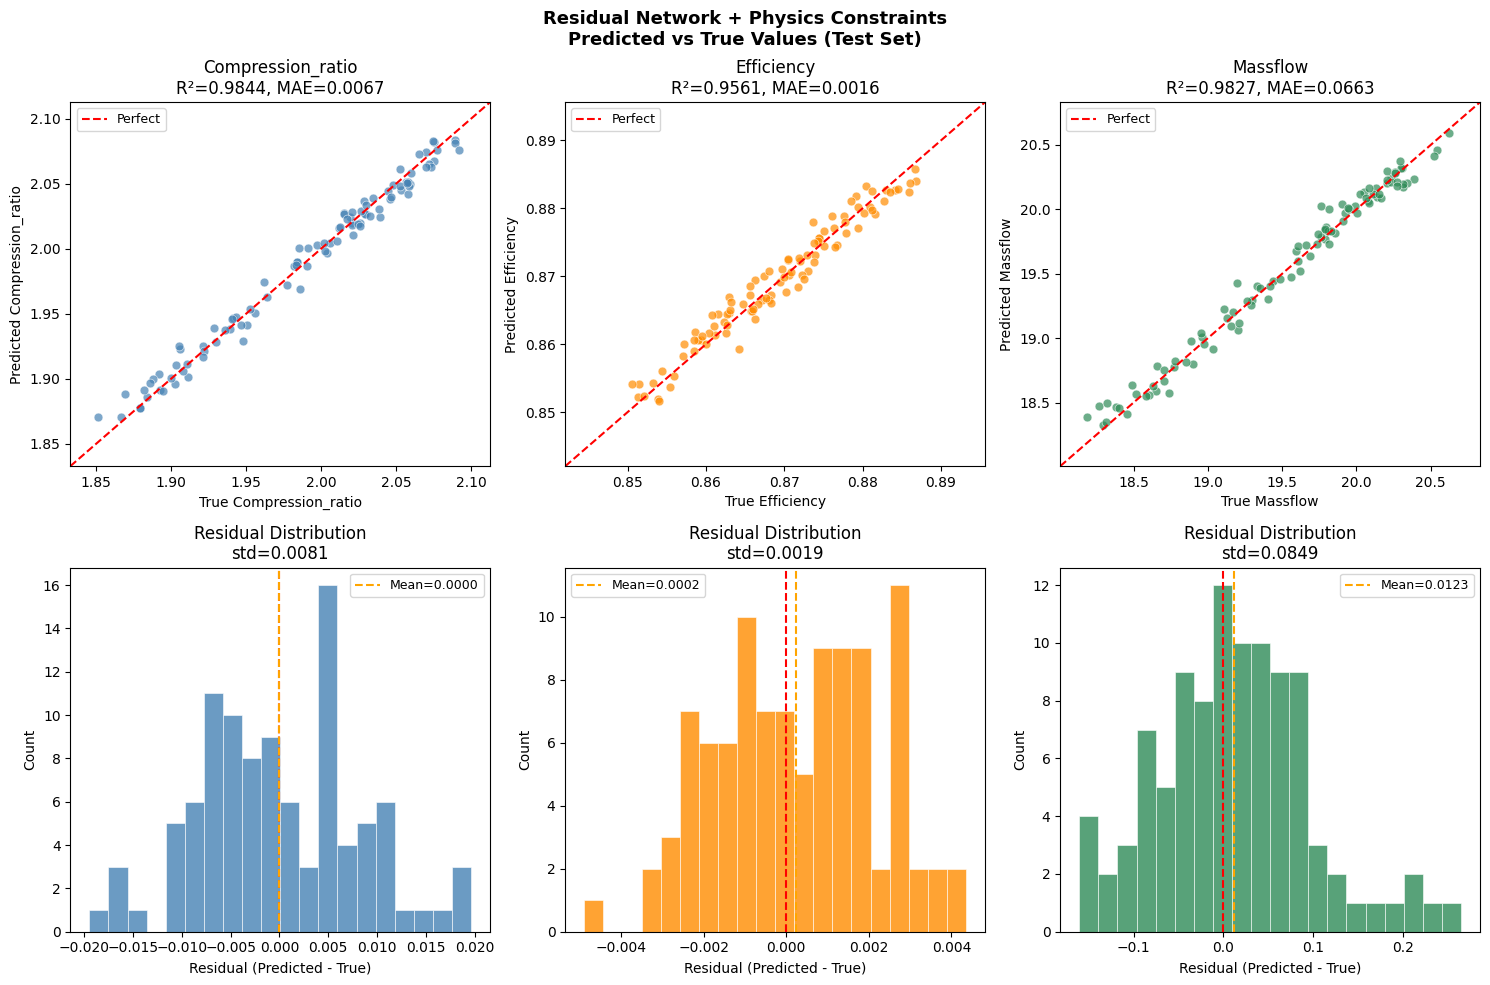

✅ 图10已保存


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Residual Network + Physics Constraints\n'
             'Predicted vs True Values (Test Set)',
             fontsize=13, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen']

for i, (col, color) in enumerate(zip(output_cols, colors)):
    y_t = y_true_orig[:, i]
    y_p = y_pred_orig[:, i]
    r2  = r2_score(y_t, y_p)
    mae = mean_absolute_error(y_t, y_p)
    residuals = y_p - y_t

    # 上方：预测 vs 真实散点图
    ax = axes[0, i]
    ax.scatter(y_t, y_p, color=color, alpha=0.7, s=40,
               edgecolors='white', linewidth=0.5)
    lims = [min(y_t.min(), y_p.min())*0.99,
            max(y_t.max(), y_p.max())*1.01]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'True {col}')
    ax.set_ylabel(f'Predicted {col}')
    ax.set_title(f'{col}\nR²={r2:.4f}, MAE={mae:.4f}')
    ax.legend(fontsize=9)

    # 下方：残差分布图（预测误差的分布）
    ax2 = axes[1, i]
    ax2.hist(residuals, bins=20, color=color,
             edgecolor='white', linewidth=0.5, alpha=0.8)
    ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax2.axvline(residuals.mean(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f'Mean={residuals.mean():.4f}')
    ax2.set_xlabel(f'Residual (Predicted - True)')
    ax2.set_ylabel('Count')
    ax2.set_title(f'Residual Distribution\nstd={residuals.std():.4f}')
    ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../docs/fig10_residual_model_evaluation.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图10已保存")

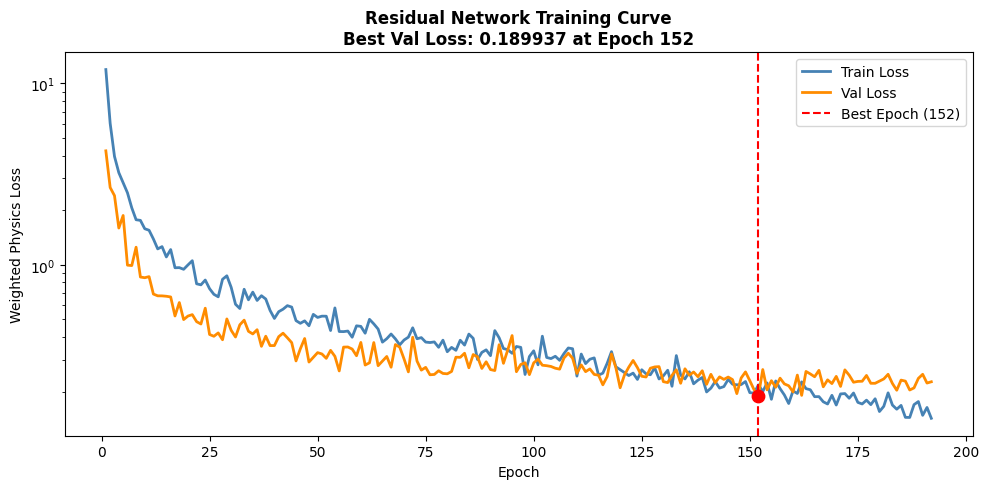

✅ 图11已保存


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(1, len(train_losses)+1)
ax.plot(epochs_range, train_losses,
        label='Train Loss', color='steelblue', linewidth=2)
ax.plot(epochs_range, val_losses,
        label='Val Loss', color='darkorange', linewidth=2)
ax.axvline(best_epoch, color='red', linestyle='--',
           linewidth=1.5, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_val_loss], color='red', s=80, zorder=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted Physics Loss')
ax.set_title('Residual Network Training Curve\n'
             f'Best Val Loss: {best_val_loss:.6f} at Epoch {best_epoch}',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig("../docs/fig11_residual_training_curve.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图11已保存")

## 📊 Day 6 残差网络 + 物理约束 总结

### 相比基线MLP的核心升级

| 升级点 | 基线MLP | 残差网络 |
|--------|---------|---------|
| 网络结构 | 顺序MLP | 残差连接（跳跃连接） |
| 损失函数 | 普通MSE | 加权MSE + 物理约束惩罚 |
| 效率权重 | 1.0× | 3.0×（专门提升效率R²） |
| 物理约束 | 无 | 效率∈[0.5,1]，压比≥1，流量≥0 |
| 学习率调度 | ReduceLROnPlateau | CosineAnnealingLR |
| 梯度保护 | 无 | gradient clipping (max_norm=1.0) |

### 物理约束的意义
- 效率预测永远不会超过1（热力学第二定律）
- 压比预测永远不会小于1（压气机定义）
- 这让模型具备了**物理可信度**，在内行面前站得住脚

### 下一步（Day 7）
- 如果 R² 全部 > 0.95 → 开始不确定性量化（UQ）
- 如果还有未达标 → 继续调整超参数或特征